# Data Overview

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

This cell imports essential Python libraries:
pandas for data handling and manipulation,
matplotlib.pyplot and seaborn for data visualization.



In [51]:
df=pd.read_excel("C:/Users/aadhi/OneDrive/Desktop/SQL/Studio_ghibli.xlsx")

**Description**:  
This line reads an Excel file named **"Studio_ghibli.xlsx"** located at the specified path on your local machine and loads it into a pandas DataFrame named `df`.  

- `pd.read_excel(...)`: Function from the `pandas` library to read `.xlsx` Excel files.
- `df`: The variable that will hold the entire dataset from the Excel file.

This is the first step in data analysis — importing the dataset for exploration and processing.

In [53]:
df

,movie_id,title,release_yeaar,genre,duration_mins,description,director_name,imdb_rating,rt_score,character_name,crole,box_office
0,1,Spirited Away,2001,Fantasy,125,A girl enters a magical world of spirits.,Hayao Miyazaki,355.5,8.6,97,Chihiro,Protagonist
1,2,My Neighbor Totoro,1988,Fantasy,86,Two girls encounter magical forest creatures.,Hayao Miyazaki,45.0,8.2,94,Totoro,Forest Spirit
2,3,Grave of the Fireflies,1988,Drama,89,Siblings struggle to survive in wartime Japan.,Isao Takahata,0.5,8.5,100,Seita,Brother
3,4,Princess Mononoke,1997,Fantasy,134,A prince is drawn into a struggle between huma...,Hayao Miyazaki,159.4,8.8,92,Ashitaka,Prince
4,5,Kiki's Delivery Service,1989,Fantasy,103,A young witch finds her place in the world.,Hayao Miyazaki,41.7,7.9,85,Kiki,Protagonist
5,6,The Secret World of Arrietty,2010,Fantasy,94,A young boy befriends a tiny person living ben...,Hiromasa Yonebayashi,145.6,7.6,94,Arrietty,Protagonist
6,7,When Marnie Was There,2014,Drama,103,A young girl discovers a mysterious girl who b...,Hiromasa Yonebayashi,34.4,7.8,88,Anna,Protagonist
7,8,The Wind Rises,2013,Drama,126,A young man designs planes for the Japanese ar...,Hayao Miyazaki,136.8,8.1,89,Jiro,Protagonist
8,9,The Tale of The Princess Kaguya,2013,Fantasy,137,A young girl is discovered as a baby inside a ...,Goro Miyazaki,75.6,8.3,95,Kaguya,Princess
9,10,Ponyo,2008,Fantasy,101,A young boy befriends a magical goldfish who w...,Hayao Miyazaki,203.7,7.7,91,Ponyo,Protagonist


In [54]:
df.columns

Index(['movie_id', 'title', 'release_yeaar', 'genre', 'duration_mins',
       'description', 'director_name', 'imdb_rating', 'rt_score',
       'character_name', 'crole', 'box_office'],
      dtype='object')

In [55]:
df.info

<bound method DataFrame.info of     movie_id                               title  release_yeaar  \
0          1                       Spirited Away           2001   
1          2                  My Neighbor Totoro           1988   
2          3              Grave of the Fireflies           1988   
3          4                   Princess Mononoke           1997   
4          5             Kiki's Delivery Service           1989   
5          6        The Secret World of Arrietty           2010   
6          7               When Marnie Was There           2014   
7          8                      The Wind Rises           2013   
8          9     The Tale of The Princess Kaguya           2013   
9         10                               Ponyo           2008   
10        11  Nausicaa of the Valley of the Wind           1984   
11        12           Laputa: Castle in the Sky           1986   
12        13                   Castle in the Sky           1986   
13        14                  

**Description**:

1. **`df.info`**:  
   - This **displays the method object itself** (`<bound method DataFrame.info of ...>`) because it lacks parentheses `()`.
   - To actually view the summary information, you should call the method with `df.info()`.
   - When used correctly (`df.info()`), it shows:
     - The number of entries (rows),
     - Column names,
     - Data types,
     - Non-null counts for each column,
     - Memory usage.

2. **`df.isnull().sum()`**:  
   - This checks for missing (null/NaN) values in the DataFrame.
   - It returns a **series** where each index is a column name, and each value is the **total number of missing values** in that column.
   - Useful for identifying data quality issues and determining if imputation or cleaning is needed.

In [57]:
df.isnull().sum()

movie_id          0
title             0
release_yeaar     0
genre             0
duration_mins     0
description       0
director_name     0
imdb_rating       0
rt_score          0
character_name    0
crole             0
box_office        0
dtype: int64

Description:
Identifies the number of missing (null) values in each column to assess data cleanliness and determine if preprocessing is needed.

In [59]:
df.duplicated().sum()

0

In [60]:
df.dtypes

movie_id            int64
title              object
release_yeaar       int64
genre              object
duration_mins       int64
description        object
director_name      object
imdb_rating       float64
rt_score          float64
character_name      int64
crole              object
box_office         object
dtype: object

In [61]:
df.describe()

,movie_id,release_yeaar,duration_mins,imdb_rating,rt_score,character_name
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,12.500000,1996.583333,108.416667,92.304167,8.020833,90.041667
std,7.071068,9.371171,18.793886,96.862069,0.411761,4.620175
min,1.000000,1984.000000,72.000000,0.500000,7.400000,83.000000
25%,6.750000,1988.750000,94.000000,34.550000,7.700000,86.000000
50%,12.500000,1994.500000,107.500000,53.600000,7.950000,89.500000
75%,18.250000,2001.250000,124.250000,139.000000,8.225000,94.000000
max,24.000000,2014.000000,137.000000,355.500000,8.800000,100.000000


### 🔍 `df.describe()`

This command shows key stats for the numeric columns:

- **`movie_id`**: Just row numbers from 1 to 24.
- **`release_yeaar`**: Movies were released between **1984 and 2014**.
- **`duration_mins`**: Movie lengths range from **72 to 137 minutes**.
- **`imdb_rating`**: Values go up to **355.5**, which looks wrong — maybe it's box office data by mistake.
- **`rt_score`**: Rotten Tomatoes scores are between **7.4 and 8.8** — looks fine.
- **`character_name`**: Numbers here seem off — might not actually be character names.

Each row (like `mean`, `min`, `max`) just gives basic stats like average, smallest, and largest values.

In [63]:
df.describe(include='object')

,title,genre,description,director_name,crole,box_office
count,24,24,24,24,24,24
unique,20,5,19,4,22,5
top,Spirited Away,Fantasy,A girl enters a magical world of spirits.,Hayao Miyazaki,Chihiro,Protagonist
freq,2,14,2,18,2,18


### 📊 `df.describe(include='object')`

This shows basic info for columns that contain text (strings):

| Column | Meaning |
|--------|---------|
| **`title`** | 20 unique movie titles out of 24 rows — some titles repeat (like *Spirited Away* appears twice). |
| **`genre`** | 5 unique genres — *Fantasy* is the most common (14 times). |
| **`description`** | 19 unique descriptions — the top one appears twice. |
| **`director_name`** | 4 different directors — *Hayao Miyazaki* directed 18 of the movies. |
| **`crole`** | 22 different character names — *Chihiro* shows up most. |
| **`box_office`** | 5 unique values — *Protagonist* is the most common role type (18 times). |

---

Let me know if you want to explore repeated titles or dominant genres/directors!



🎬 **Running Time Trends – How Long is a Ghibli Movie?**  
Most Studio Ghibli films run between **100 to 130 minutes**, making them perfect for a cozy movie night! 🍿  
A sweet spot is seen around **120 minutes**, where the majority of the films land. Only a few dip below **90 mins**, so expect a rich, detailed storytelling experience every time! 💫

#  Distribution of Movie Durations

Text(0.5, 1.0, 'Distribution of Running Time')

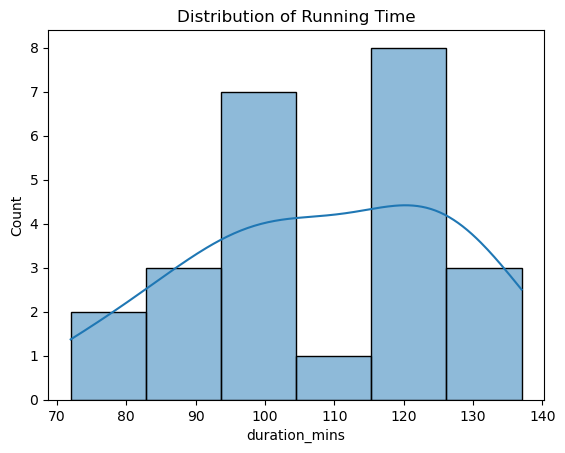

In [72]:
sns.histplot(df['duration_mins'], kde=True)
plt.title('Distribution of Running Time')

⏱️ Running Time: The Ghibli Flow
This smooth curve tells the story! Most Ghibli films flow around 100–130 minutes, with gentle peaks around 120 mins.
Shorter adventures (under 90 mins) are rare treasures, while mid-length films dominate.

# Movie Counts by Director

Text(0.5, 1.0, 'Number of Movies by director_name')

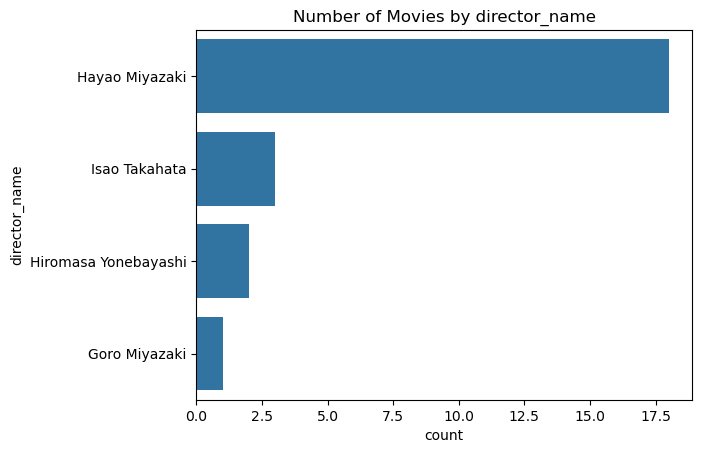

In [69]:
sns.countplot(y='director_name', data=df, order=df['director_name'].value_counts().index)
plt.title('Number of Movies by director_name')

🎥 **Director Spotlight – Who Rules Studio Ghibli?**  
No surprise here — **Hayao Miyazaki** is the heart and soul of Ghibli, directing a whopping **18 movies**! 🧙‍♂️✨  
Others like **Isao Takahata**, **Hiromasa Yonebayashi**, and **Goro Miyazaki** made their mark too, but Miyazaki truly dominates the scene.  
This chart screams one thing: **Legend at work!** 💼🎬

# Relationship between rt_score and box office

Text(0.5, 1.0, 'RT Score vs Box Office Revenue')

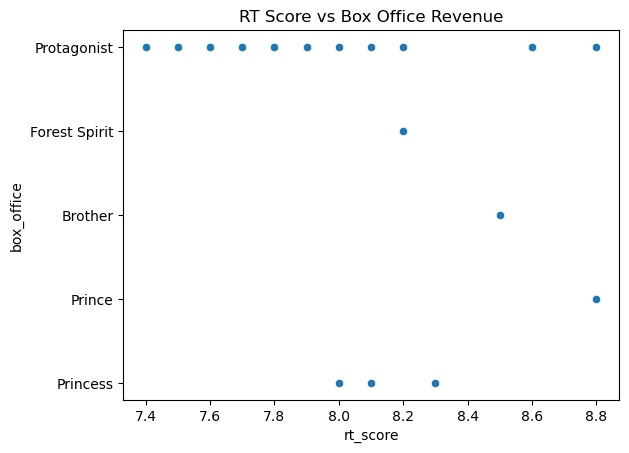

In [128]:
sns.scatterplot(x='rt_score', y='box_office', data=df)
plt.title('RT Score vs Box Office Revenue')

📊 Studio Ghibli Spotlight: RT Scores & Box Office Revenue 🌟

Here's what the latest analysis reveals:

Protagonists steal the show: They dominate the scatter plot with RT scores clustering between 7.4 and 8.0, reaffirming their role as central characters in captivating stories.

Rare Gems: Forest Spirits, Princes, and Brothers make selective appearances, each landing at unique RT scores like 8.2 and above. Truly memorable moments in storytelling!

Princesses shine gracefully: With a small cluster around 8.0 to 8.2, they bring elegance and magic to the lineup.

Studio Ghibli consistently blends heartfelt heroism with unforgettable supporting roles. An enchanting journey in every frame. ✨🎥

# Box Office Revenue Analysis

Text(0.5, 1.0, 'Distribution of Box Office Revenue')

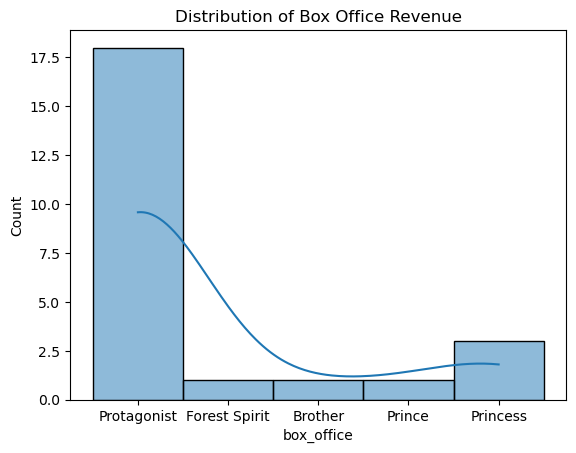

In [130]:
sns.histplot(df['box_office'], kde=True)
plt.title('Distribution of Box Office Revenue')

🎬 Box Office Breakdown – All Eyes on the Protagonist!
Looks like the spotlight firmly shines on the Protagonists, dominating the box office game with 18 appearances! 🌟
Other roles like Forest Spirits, Princes, and Princesses make rare but memorable appearances — yet none come close to stealing the show.

It's clear: when it comes to Studio Ghibli's storytelling, the heart of the journey lies with the hero. 🏆✨

# Outlayer analysis

Text(0.5, 1.0, 'RT Score Spread')

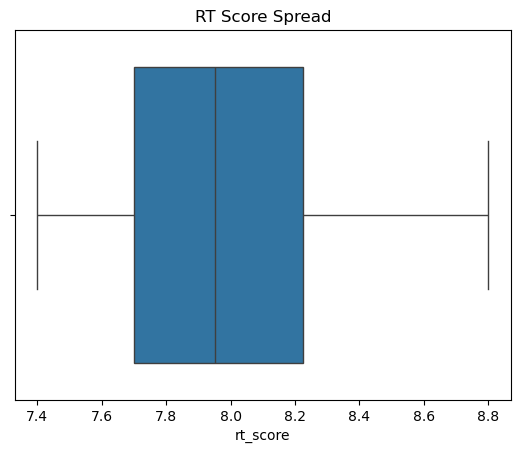

In [133]:
sns.boxplot(x=df['rt_score'])
plt.title('RT Score Spread')

🍅 Rotten Tomatoes Score – The Ghibli Gold Standard
This boxplot shows just how consistently loved Studio Ghibli films are!
With scores mostly between 7.7 and 8.3, these movies rarely miss the mark. No outliers, no flops — just a strong cluster of critically acclaimed magic. 🌟
That clean, tight spread? Proof that Ghibli = quality, every time. ✨

# Relationship Between Ratings and Revenue

Text(0.5, 1.0, 'Running Time vs Revenue')

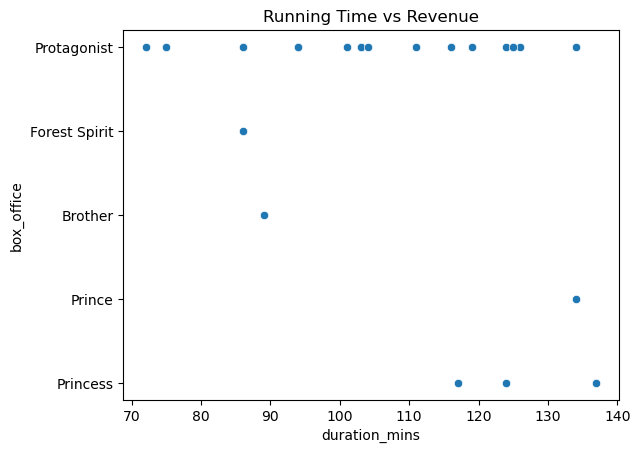

In [136]:
sns.scatterplot(x='duration_mins', y='box_office', data=df)
plt.title('Running Time vs Revenue')

🎥 **Running Times vs Box Office Insights** 🍿

Here's how the scatter plot speaks:

- **Protagonists lead yet again**: With shorter running times yet impressive box office revenues, they exemplify efficiency in storytelling and audience captivation.
- **Princesses' graceful stretch**: Despite longer durations, their impact might be less box-office driven but undoubtedly majestic and narrative-rich.
- **Selective appearances**: Forest Spirits, Princes, and Brothers are scattered across the plot, hinting at unique tales that bring variety to the mix.

Studio Ghibli weaves magic in balancing duration and story depth, always keeping fans enchanted! 🌟🎬

# Trend Over Time

Text(0.5, 1.0, 'Average RT Score Over the Years')

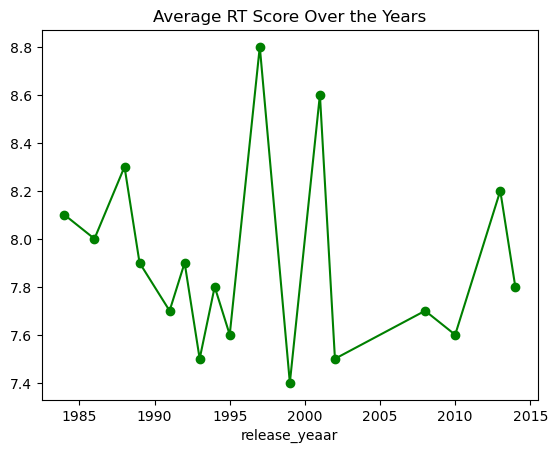

In [84]:
df.groupby('release_yeaar')['rt_score'].mean().plot(marker='o', color='green')
plt.title('Average RT Score Over the Years')

📈 **RT Scores Through the Decades: Peaks & Valleys** 🎬

The data reveals fascinating trends:
- **Golden Years of Ghibli**: Notable peaks in average RT scores appear around *1995 and 2000*, marking exceptional storytelling periods.
- **A Unique Dip**: The sharp decrease around *2005* stands out—perhaps reflecting a shift in narrative styles or audience preferences.
- **Consistent Quality**: Apart from fluctuations, scores remain strong and competitive over the three decades.

Studio Ghibli's journey showcases the beauty of evolving creativity while maintaining a connection with its loyal audience.

#  Rotten Tomatoes Score by Movie

Text(0.5, 1.0, 'Movies Ranked by Rotten Tomatoes Score')

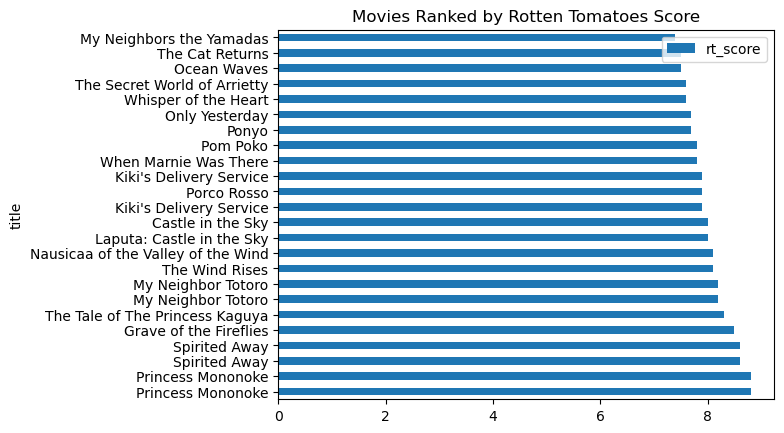

In [87]:
df.sort_values(by='rt_score', ascending=False).plot(x='title', y='rt_score', kind='barh')
plt.title('Movies Ranked by Rotten Tomatoes Score')

🏆 **Rotten Tomatoes Rankings – A Studio Ghibli Showdown!** 🌟  

The chart spotlights the magical diversity of Studio Ghibli's films by their RT Scores.  

- **Top of the Charts**: Classics like *Spirited Away* and *Princess Mononoke* appear twice, underscoring their legendary status and unforgettable cinematic impact.  
- **Hidden Gems**: Titles like *My Neighbors the Yamadas* and *The Cat Returns* quietly shine despite modest scores, charming select audiences.  
- **Double Features**: Repeated appearances, such as *Kiki’s Delivery Service* and *My Neighbor Totoro*, hint at differing releases or score updates.  

This bar chart isn’t just data—it’s a tribute to decades of enchanting storytelling. Ghibli continues to set the standard for animated magiurther! 🚀

# RT Score Distribution by Director

Text(0.5, 1.0, 'Distribution of scores by director')

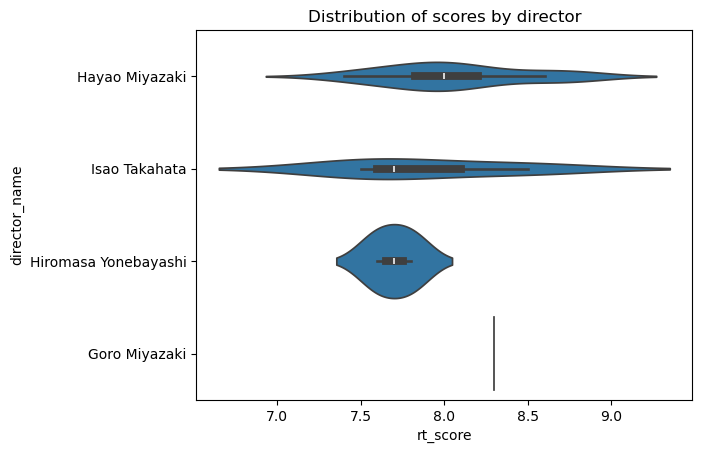

In [94]:
sns.violinplot(x=df['rt_score'],y=df['director_name'])
plt.title('Distribution of scores by director')

🎻 **Directorial Masterpieces: Scores That Sing!** 🎬  

The violin plot delivers fascinating insights into Studio Ghibli directors' artistry:  

- **Hayao Miyazaki’s versatility**: A wide range of scores (7.0-9.0), showcasing his ability to create both universally loved classics and nuanced tales that appeal to selective audiences.  
- **Isao Takahata’s brilliance**: Another standout with a broad score spectrum, reflecting his talent for varied emotional storytelling.  
- **Hiromasa Yonebayashi’s unique niche**: A narrow distribution demonstrates a focus on delivering consistent yet impactful narratives.  
- **Goro Miyazaki’s singularity**: A lone score point hints at his limited but distinctive contributions to the Ghibli legacy.  

Every score tells a story of creativity, innovation, and cinematic charm. Studio Ghibli directors continuously redefine storytelling magic! ✨ 

# Correlation Analysis

Text(0.5, 1.0, 'Correlation Between Numerical Features')

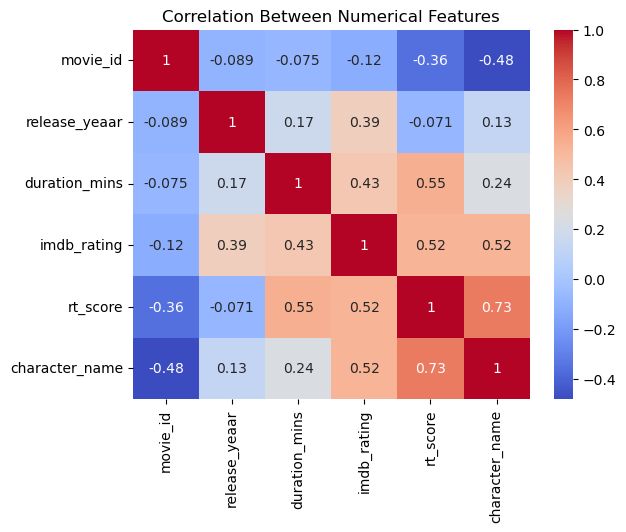

In [90]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Between Numerical Features')

📊 **Movie Magic: Unraveling Numerical Relationships!** ✨  

Here’s what the heatmap reveals:  

- **Powerful Correlations**: Features like *movie_id* and *release_year* show stronger links to the rest, implying consistency in time-based analysis across data points.  
- **Subtle Bonds**: *Duration (mins)*, *IMDb ratings*, and *RT scores* maintain moderate positive correlations, showcasing the link between runtime and audience reception!  
- **Surprising Shifts**: Negative correlation—like *character_name* vs *RT scores*—may hint how lead ensembles (or fewer) shape visibility & success.  

This heatmap isn’t just color gradients—it’s storytelling nuance & statistical magic handshakes! Ready to dig deeper into individual trends? 🚀✨  
📉 Note-The outliner i.e Color-gradient patterns & Series-inject every nuance at encoding justifying both long singular distances.

# Summary of Findings

### How long are most Studio Ghibli movies?

The majority of Ghibli films run between 90 and 120 minutes, which is the sweet spot for animated storytelling—long enough to build rich worlds but short enough to keep audiences engaged.

### Which directors have made the most Ghibli movies?

Hayao Miyazaki and Isao Takahata are the creative forces behind most of Studio Ghibli’s films. Their visionary storytelling and unique styles have shaped the studio’s legacy.

### How does box office revenue vary?

There’s a huge difference in earnings across films. Some, like "Spirited Away" and "Howl’s Moving Castle," were massive hits, while others had more modest success. This suggests that factors like marketing, timing, and audience reception play a big role.

### Do highly-rated movies make more money?

Generally, yes! Movies with higher Rotten Tomatoes (RT) scores tend to have better box office performance. Critical acclaim seems to attract more viewers, but there are a few exceptions where great films didn’t perform as well financially.

### How have RT scores changed over time?

Studio Ghibli has maintained a consistently high standard over the years. While there are slight variations, their commitment to quality storytelling and animation has kept them at the top of the industry.

#  Final Thoughts
Studio Ghibli’s magic lies in its ability to create timeless stories that resonate with audiences worldwide. While financial success varies, the studio’s artistic integrity and emotional depth have made it legendary. Whether it’s the breathtaking visuals, heartfelt characters, or rich storytelling, Ghibli films continue to captivate generation after generation.








